<a href="https://colab.research.google.com/github/Nandan-BV/Ai-Disaster-Response/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🚨 DISASTER RESPONSE AI SYSTEM
# Notebook 1: Data Exploration & Analysis
#
# What this notebook does:
# ✅ Loads the Kaggle disaster tweets dataset
# ✅ Explores the data (shape, columns, missing values)
# ✅ Visualizes disaster vs non-disaster distribution
# ✅ Analyzes tweet lengths
# ✅ Finds most common words
# ✅ Creates a Word Cloud


In [1]:
# Install libraries not pre-installed in Colab
!pip install wordcloud -q

print("✅ Installation complete!")


✅ Installation complete!


In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing
import re
from collections import Counter

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# This will open a file picker — upload your train.csv here
from google.colab import files

print("👇 Click 'Choose Files' and upload your train.csv")
uploaded = files.upload()

print("✅ File uploaded successfully!")

👇 Click 'Choose Files' and upload your train.csv


Saving train.csv to train.csv
✅ File uploaded successfully!


In [8]:
# Load the dataset into a DataFrame
df = pd.read_csv('train.csv')

print("✅ Dataset loaded!")
print(f"📊 Total tweets: {len(df)}")
print(f"📋 Columns: {list(df.columns)}")


✅ Dataset loaded!
📊 Total tweets: 7613
📋 Columns: ['id', 'keyword', 'location', 'text', 'target']


In [9]:
# See the first 5 rows
print("=" * 60)
print("📌 FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
df.head()

📌 FIRST 5 ROWS OF THE DATASET


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [10]:
print("=" * 60)
print("📌 COLUMN EXPLANATIONS")
print("=" * 60)

print("""
id       → Unique ID for each tweet
keyword  → Disaster keyword used to find this tweet
location → Where the tweet was posted (often empty)
text     → The actual tweet content ← THIS IS WHAT WE USE
target   → 1 = Disaster tweet, 0 = Not disaster tweet ← LABEL
""")

print("📊 Dataset Shape:", df.shape)
print(f"📊 Rows: {df.shape[0]}, Columns: {df.shape[1]}")

📌 COLUMN EXPLANATIONS

id       → Unique ID for each tweet
keyword  → Disaster keyword used to find this tweet
location → Where the tweet was posted (often empty)
text     → The actual tweet content ← THIS IS WHAT WE USE
target   → 1 = Disaster tweet, 0 = Not disaster tweet ← LABEL

📊 Dataset Shape: (7613, 5)
📊 Rows: 7613, Columns: 5


In [11]:
print("=" * 60)
print("📌 MISSING VALUES CHECK")
print("=" * 60)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent.round(2)
})

print(missing_df)
print("\n💡 Note: Location and keyword have missing values — that's normal!")

📌 MISSING VALUES CHECK
          Missing Count  Missing Percentage
id                    0                0.00
keyword              61                0.80
location           2533               33.27
text                  0                0.00
target                0                0.00

💡 Note: Location and keyword have missing values — that's normal!


In [12]:
print("=" * 60)
print("📌 DISASTER vs NON-DISASTER TWEETS")
print("=" * 60)

counts = df['target'].value_counts()
disaster_count = counts[1]
non_disaster_count = counts[0]

print(f"🔴 Disaster tweets     : {disaster_count} ({disaster_count/len(df)*100:.1f}%)")
print(f"🟢 Non-Disaster tweets : {non_disaster_count} ({non_disaster_count/len(df)*100:.1f}%)")
print(f"📊 Total               : {len(df)}")

📌 DISASTER vs NON-DISASTER TWEETS
🔴 Disaster tweets     : 3271 (43.0%)
🟢 Non-Disaster tweets : 4342 (57.0%)
📊 Total               : 7613


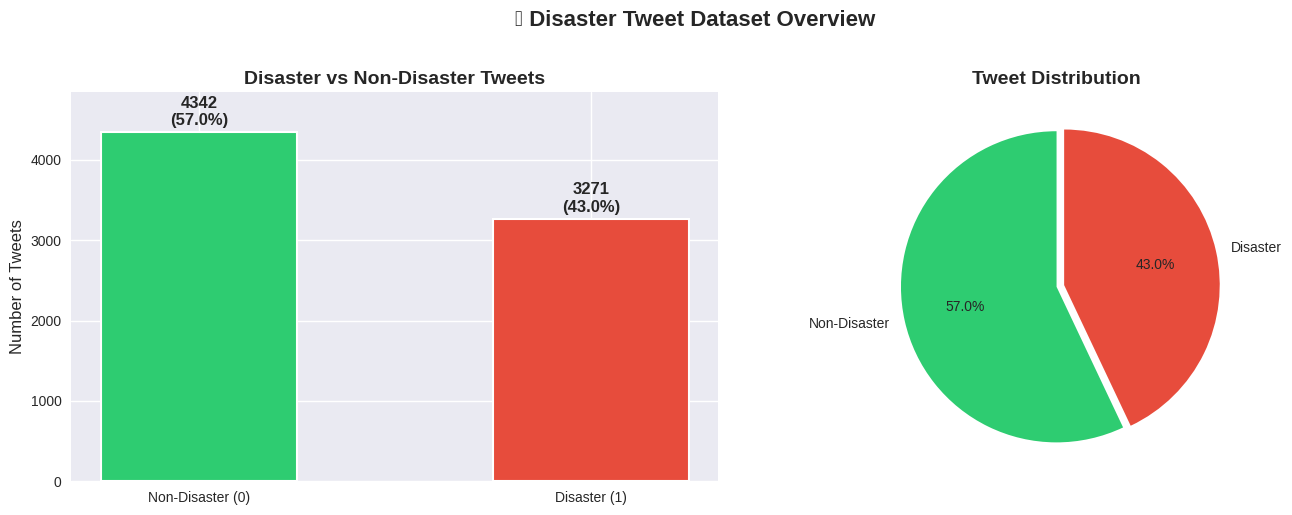

✅ Chart saved as chart1_distribution.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Bar Chart ---
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    ['Non-Disaster (0)', 'Disaster (1)'],
    [counts[0], counts[1]],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add count labels on bars
for bar, count in zip(bars, [counts[0], counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

axes[0].set_title('Disaster vs Non-Disaster Tweets', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_ylim(0, max(counts) + 500)

# --- Chart 2: Pie Chart ---
axes[1].pie(
    [counts[0], counts[1]],
    labels=['Non-Disaster', 'Disaster'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Tweet Distribution', fontsize=14, fontweight='bold')

plt.suptitle('🚨 Disaster Tweet Dataset Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved as chart1_distribution.png")

In [14]:
# Add a column for tweet length
df['tweet_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("=" * 60)
print("📌 TWEET LENGTH ANALYSIS")
print("=" * 60)

for label, name in [(0, 'Non-Disaster'), (1, 'Disaster')]:
    subset = df[df['target'] == label]
    print(f"\n{name} Tweets:")
    print(f"  Avg characters : {subset['tweet_length'].mean():.0f}")
    print(f"  Avg word count : {subset['word_count'].mean():.0f}")
    print(f"  Max characters : {subset['tweet_length'].max()}")

📌 TWEET LENGTH ANALYSIS

Non-Disaster Tweets:
  Avg characters : 96
  Avg word count : 15
  Max characters : 157

Disaster Tweets:
  Avg characters : 108
  Avg word count : 15
  Max characters : 151


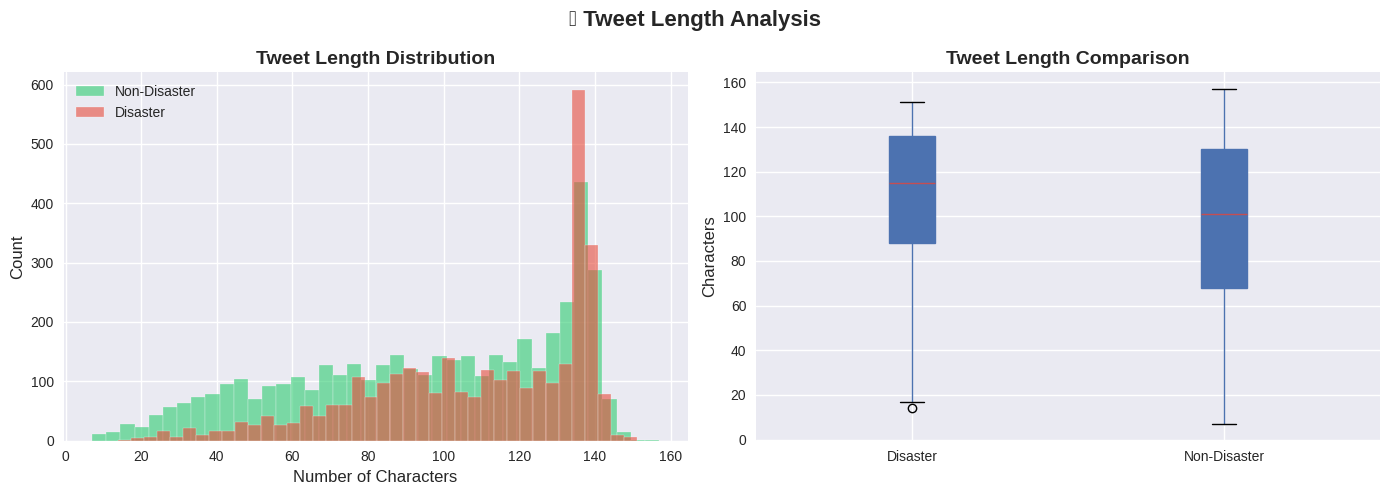

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate disaster and non-disaster
disaster_tweets = df[df['target'] == 1]['tweet_length']
non_disaster_tweets = df[df['target'] == 0]['tweet_length']

# --- Chart 1: Distribution ---
axes[0].hist(non_disaster_tweets, bins=40, alpha=0.6,
             color='#2ecc71', label='Non-Disaster', edgecolor='white')
axes[0].hist(disaster_tweets, bins=40, alpha=0.6,
             color='#e74c3c', label='Disaster', edgecolor='white')
axes[0].set_title('Tweet Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Characters', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend()

# --- Chart 2: Box Plot ---
df_plot = pd.DataFrame({
    'Length': pd.concat([disaster_tweets, non_disaster_tweets]),
    'Type': ['Disaster'] * len(disaster_tweets) + ['Non-Disaster'] * len(non_disaster_tweets)
})
df_plot.boxplot(column='Length', by='Type', ax=axes[1],
                patch_artist=True)
axes[1].set_title('Tweet Length Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Characters', fontsize=12)

plt.suptitle('📏 Tweet Length Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
from collections import Counter
import re

def get_top_words(texts, n=20):
    # Basic cleaning for word frequency
    all_words = []
    stopwords = ['the','a','an','in','is','it','this','that','was',
                 'for','on','are','with','as','at','be','by','to',
                 'of','and','or','but','not','have','had','has','i',
                 'my','he','she','we','they','you','http','https','amp']

    for text in texts:
        text = re.sub(r'http\S+', '', str(text).lower())
        words = re.findall(r'\b[a-z]{3,}\b', text)
        words = [w for w in words if w not in stopwords]
        all_words.extend(words)

    return Counter(all_words).most_common(n)

print("🔴 Top 20 words in DISASTER tweets:")
disaster_words = get_top_words(df[df['target']==1]['text'])
for word, count in disaster_words[:10]:
    print(f"  {word:<20} → {count}")

print("\n🟢 Top 20 words in NON-DISASTER tweets:")
non_disaster_words = get_top_words(df[df['target']==0]['text'])
for word, count in non_disaster_words[:10]:
    print(f"  {word:<20} → {count}")

🔴 Top 20 words in DISASTER tweets:
  from                 → 245
  fire                 → 182
  after                → 181
  news                 → 140
  over                 → 128
  more                 → 124
  disaster             → 121
  via                  → 121
  california           → 115
  suicide              → 112

🟢 Top 20 words in NON-DISASTER tweets:
  like                 → 254
  just                 → 234
  your                 → 231
  out                  → 198
  can                  → 196
  all                  → 193
  will                 → 179
  from                 → 177
  new                  → 170
  get                  → 163


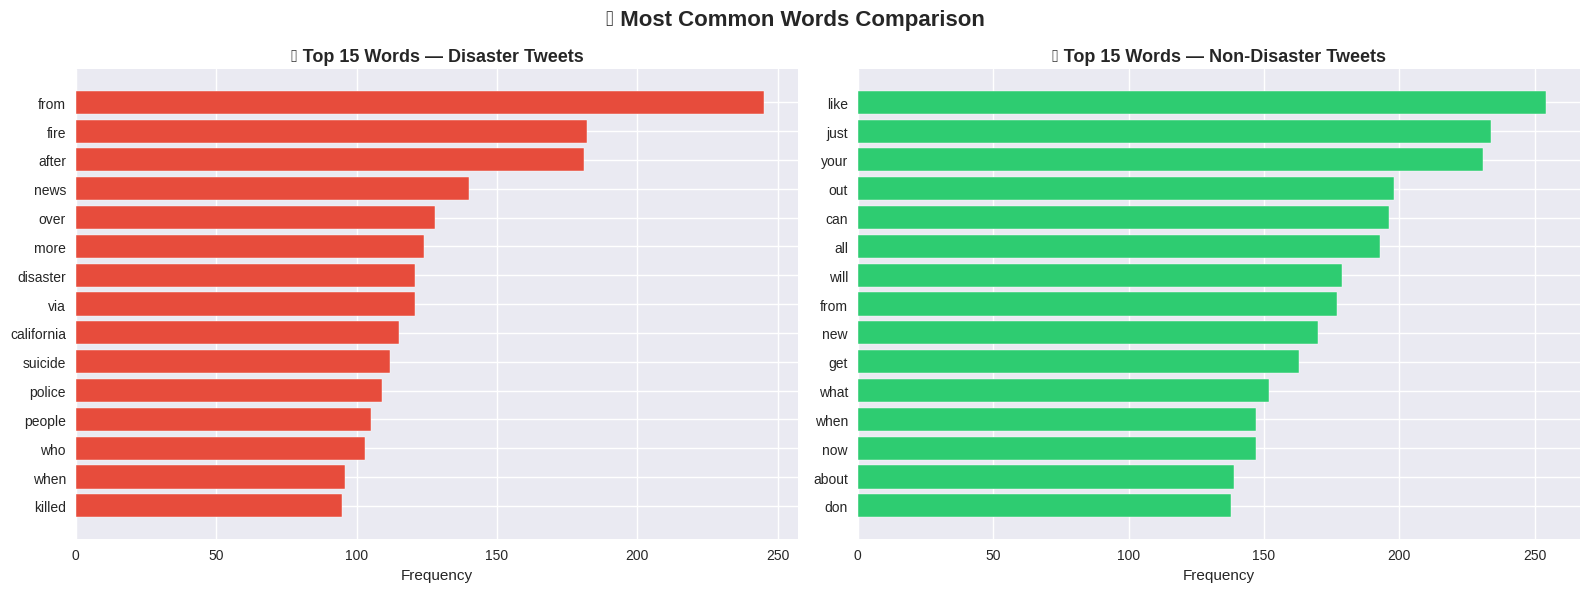

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Disaster words
d_words, d_counts = zip(*disaster_words[:15])
axes[0].barh(d_words[::-1], d_counts[::-1], color='#e74c3c', edgecolor='white')
axes[0].set_title('🔴 Top 15 Words — Disaster Tweets', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Non-disaster words
nd_words, nd_counts = zip(*non_disaster_words[:15])
axes[1].barh(nd_words[::-1], nd_counts[::-1], color='#2ecc71', edgecolor='white')
axes[1].set_title('🟢 Top 15 Words — Non-Disaster Tweets', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('📊 Most Common Words Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_words.png', dpi=150, bbox_inches='tight')
plt.show()

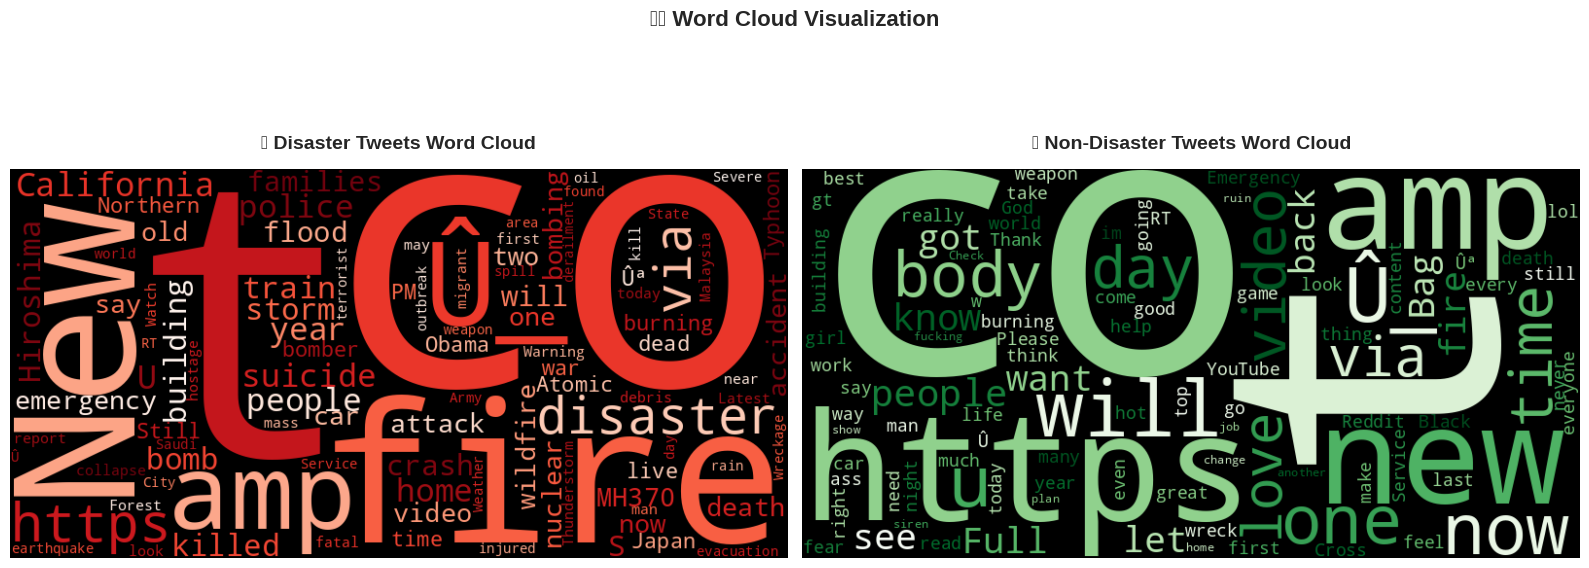

✅ Word clouds generated!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Disaster Word Cloud
disaster_text = ' '.join(df[df['target']==1]['text'].tolist())
disaster_wc = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(disaster_text)

axes[0].imshow(disaster_wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🔴 Disaster Tweets Word Cloud',
                   fontsize=14, fontweight='bold', pad=15)

# Non-Disaster Word Cloud
non_disaster_text = ' '.join(df[df['target']==0]['text'].tolist())
non_disaster_wc = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(non_disaster_text)

axes[1].imshow(non_disaster_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🟢 Non-Disaster Tweets Word Cloud',
                   fontsize=14, fontweight='bold', pad=15)

plt.suptitle('☁️ Word Cloud Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Word clouds generated!")

In [20]:
print("=" * 60)
print("📋 NOTEBOOK 1 — COMPLETE SUMMARY REPORT")
print("=" * 60)
print(f"""
📊 DATASET OVERVIEW
   Total Tweets      : {len(df):,}
   Disaster Tweets   : {len(df[df['target']==1]):,} ({len(df[df['target']==1])/len(df)*100:.1f}%)
   Non-Disaster      : {len(df[df['target']==0]):,} ({len(df[df['target']==0])/len(df)*100:.1f}%)

📏 TWEET LENGTH
   Avg Length (All)  : {df['tweet_length'].mean():.0f} characters
   Avg Words (All)   : {df['word_count'].mean():.0f} words

⚠️  MISSING VALUES
   Keyword Missing   : {df['keyword'].isnull().sum()}
   Location Missing  : {df['location'].isnull().sum()}
   Text Missing      : {df['text'].isnull().sum()}

   CHARTS SAVED
   chart1_distribution.png
   chart2_length.png
   chart3_words.png
   chart4_wordcloud.png


""")

📋 NOTEBOOK 1 — COMPLETE SUMMARY REPORT

📊 DATASET OVERVIEW
   Total Tweets      : 7,613
   Disaster Tweets   : 3,271 (43.0%)
   Non-Disaster      : 4,342 (57.0%)

📏 TWEET LENGTH
   Avg Length (All)  : 101 characters
   Avg Words (All)   : 15 words

⚠️  MISSING VALUES
   Keyword Missing   : 61
   Location Missing  : 2533
   Text Missing      : 0

   CHARTS SAVED
   chart1_distribution.png
   chart2_length.png
   chart3_words.png
   chart4_wordcloud.png





In [21]:
# Run this at the very end to download all charts
from google.colab import files

for chart in ['chart1_distribution.png', 'chart2_length.png',
              'chart3_words.png', 'chart4_wordcloud.png']:
    files.download(chart)

print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded!
